In [29]:
import torch
import torch.nn as nn
from torch.nn import functional as F

In [30]:
# for downloading the dataset
!curl -o input.txt https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1089k  100 1089k    0     0      0      0 --:--:-- --:--:-- --:--:--     04423k      0 --:--:-- --:--:-- --:--:-- 4427k


In [31]:
#total number of characters in text
len(text) 


1115394

In [6]:
# first 1000 characters
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [32]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print("|".join(chars))
print(vocab_size)
chars[0], chars[1]


| |!|$|&|'|,|-|.|3|:|;|?|A|B|C|D|E|F|G|H|I|J|K|L|M|N|O|P|Q|R|S|T|U|V|W|X|Y|Z|a|b|c|d|e|f|g|h|i|j|k|l|m|n|o|p|q|r|s|t|u|v|w|x|y|z
65


('\n', ' ')

- `set()` creates a collection of all unique characters in the dataset.
- `sorted()` arranges these unique characters in ascending order.
- **Note:** the first character is a newline (`'\n'`), and the second is a space (`' '`). Both are treated as unique characters.

In [33]:
# string to integer --> dictionary of mapping from string to integer
s_to_i = { ch:i for i,ch in enumerate(chars)} 

# integer to string --> dictionary of mapping from integer to string
i_to_s = { i:ch for i,ch in enumerate(chars)}

# lambda creates a simple function in python which takes s/l as input
encode = lambda s: [s_to_i[c] for c in s]
decode = lambda l: ''.join([i_to_s[i] for i in l])      #creates list of characters then join them with null spaces

print(encode("b"))
print(decode(encode("astha-pasta")))
(decode([0,59])) , (decode([1]))

[40]
astha-pasta


('\nu', ' ')

# why subwords instead of words or characters
| Aspect | Character-level | Subword-level | Word-level |
|--------|----------------|---------------|------------|
| **Explanation** | - At the character level, the model has to learn to form subwords, then words, and finally sentences.  <br> - This is a harder task and requires significantly more training time. <br> - Even short sentences turn into very long token sequences, making harder for model to learn character that are very far away. <br> - Because LLMs generate outputs autoregressively (predicting one token at a time), more tokens mean longer prediction times and less efficiency. | - Subwords lie between character-level and word-level tokenization. <br> - With characters: tokens are very short, but vocabulary is tiny. <br> - With words: tokens are long, but vocabulary size explodes. <br> - Subwords strike a balance: a manageable vocabulary size with tokens that carry more semantic meaning than characters. | - A purely word-based vocabulary would be extremely large, making training infeasible. <br> - For example, instead of teaching the model separate tokens for *playing*, *played*, *plays*, it’s more efficient to break them into a base word + suffix (e.g., *play* + `ing`, `ed`, `s`). <br> - This way, the model can generalize across word forms, just like humans learn language — recognizing common roots and affixes. <br> - In practice, frequent words often remain whole tokens, while less common words are split into subwords, keeping the vocabulary compact while preserving richness. |


In [34]:
# data is the collection of tokens
data = torch.tensor(encode(text),dtype=torch.long)
print(data.shape, data.dtype)
data[:1000]

torch.Size([1115394]) torch.int64


tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
        47, 59, 57,  1, 47, 57,  1, 41, 

In [35]:
# splitting into training and validation set(90% training , 10% validation)
n = int(0.9*len(data))
train = data[:n]
valid= data[n:]


In [36]:
context_len= 8
train[:context_len+1] 

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

- Context length is the maximum number of tokens over which the model can learn and capture dependencies
- +1 because we are making 8 predictions(the last prediction would be using all the 8 context length)

In [37]:
for i in range(1,context_len+1):
    x = train[:i]
    y = train[i]
    print(x ,y)

tensor([18]) tensor(47)
tensor([18, 47]) tensor(56)
tensor([18, 47, 56]) tensor(57)
tensor([18, 47, 56, 57]) tensor(58)
tensor([18, 47, 56, 57, 58]) tensor(1)
tensor([18, 47, 56, 57, 58,  1]) tensor(15)
tensor([18, 47, 56, 57, 58,  1, 15]) tensor(47)
tensor([18, 47, 56, 57, 58,  1, 15, 47]) tensor(58)


- During training, the transformer is exposed to as little to maximum length of context. This helps it learn to make good predictions even when only a little context is available at inference time.

In [ ]:
torch.manual_seed(2)
batch_size = 4
context_len= 8

def get_batch(split):
    data = train if split == "train" else valid
    i_x = torch.randint(len((data)-context_len),(batch_size,1)) 
    x = torch.stack([data[i : i + context_len] for i in i_x])
    y = torch.stack([data[i+1:i+context_len+1] for i in i_x])
    return x,y

xb, yb = get_batch('train')  
xb.shape , yb.shape


(torch.Size([4, 8]), torch.Size([4, 8]))

- **`randint`** → Used for generating random integers with a given shape.  
  - It takes two arguments:  
    1. The upper limit (number up to which we want to generate).  
    2. The shape of the output.  

- **Subtracting `context_len`** → We do this because the last set is incomplete:  
  - For the last element of the last set, we don’t have any tokens that come after it.  

-  Why are we randomly sampling vectors from any part of the sentence? If we took batches sequentially, the model would be learning the complete flow of the text and have much better understanding of the text?

    - It’s like taking tiny steps in the loss landscape. At first glance, expecting small, similar changes in the gradient might sound good, but it actually **prevents the model from exploring the entire loss landscape (exploitation)**. It also **slows down convergence**, because the model doesn’t get a broader view of the full loss landscape and therefore has a harder time finding the optimal solution.

 


In [ ]:
torch.manual_seed(1337)
class BigranLanguageModel(nn.Module):
    def __init__(self,vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    # idx and targets are both (Batch , Tokens)
    def forward(self, idx, targets=None):  #this is forward pass not to be confused with a method
        
        logits = self.token_embedding_table(idx) 
        if targets is None:
            loss = None
        
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T,C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits,targets)
        
        return logits  , loss   #(batch_size, time_step , channel)
    
    def generate(self,idx,max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self(idx)   #shorthand for calling the forward method # 4 * 8 * 6
            logits = logits[:,-1,:] # 4 * 64  #we are only taking embedding corresponding to the last character of the sample we would be predicting what would be coming after that 
            probs = F.softmax(logits, dim = -1)
            idx_next = torch.multinomial(probs, num_samples=1) #4 * 1
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

m = BigranLanguageModel(vocab_size)
print(decode(m.generate(idx= torch.zeros((1,1), dtype = torch.long), max_new_tokens= 10)[0].tolist()[0]))
_ , loss = m.generate(idx= torch.zeros((1,1), dtype = torch.long), max_new_tokens= 10)
print(loss)


65

SKIcLT;AcE
None


- it is returning embedding corresponding to each token in xb , for instance if 1,2,45 is the token in the xb then it will return the embedding corresponding to these token 
- why are they called logits no idea
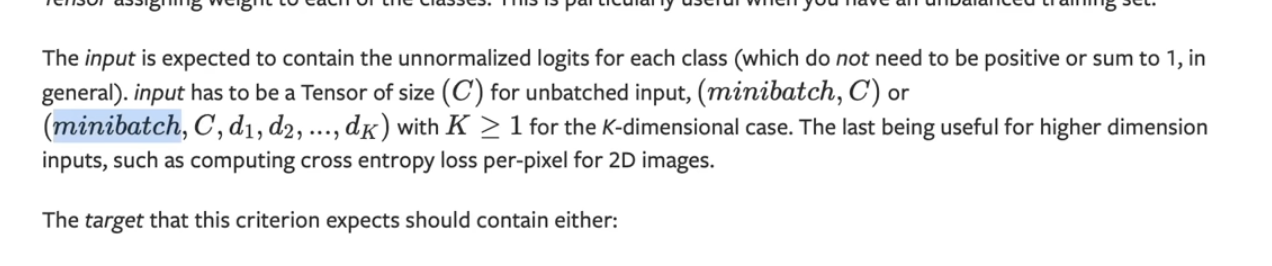
- pytorch expected the input in torch.nn.crossentropyloss to be in dim (b,c,time-step)


doubt--> so here we are comparing it with th enegative lof likehiloh of (1/65) becuase that the entropy of the random guessing so technically any model should perform better than this which mathematically equals to loss should be less than this quantity 

In [105]:
astha = torch.rand(4,8,64)
print(astha)
print("---")
astha = astha[:,-1,:]
print(astha)
print("---")
probs = F.softmax(astha, dim= -1)
print (probs)
print("---")
iish = torch.multinomial(probs, num_samples=1)
print(iish.shape)
print("---")

tensor([[[0.3433, 0.4650, 0.9860,  ..., 0.6750, 0.5032, 0.9865],
         [0.9183, 0.3556, 0.1895,  ..., 0.2476, 0.9336, 0.8904],
         [0.5440, 0.2638, 0.5859,  ..., 0.8742, 0.4107, 0.8972],
         ...,
         [0.8853, 0.0913, 0.8966,  ..., 0.1135, 0.9215, 0.0911],
         [0.3044, 0.2158, 0.1183,  ..., 0.7658, 0.3838, 0.2214],
         [0.7120, 0.3029, 0.1490,  ..., 0.5604, 0.9264, 0.8238]],

        [[0.3683, 0.3143, 0.1264,  ..., 0.9479, 0.9857, 0.3718],
         [0.8689, 0.2311, 0.0430,  ..., 0.4107, 0.3982, 0.6278],
         [0.2476, 0.1901, 0.8874,  ..., 0.8521, 0.3038, 0.0047],
         ...,
         [0.8500, 0.3044, 0.6877,  ..., 0.4714, 0.4409, 0.7388],
         [0.8462, 0.3236, 0.6754,  ..., 0.5307, 0.5507, 0.6611],
         [0.1773, 0.0510, 0.3684,  ..., 0.2123, 0.0541, 0.2995]],

        [[0.4899, 0.1043, 0.6595,  ..., 0.7503, 0.0954, 0.0272],
         [0.7499, 0.2540, 0.7578,  ..., 0.0670, 0.9023, 0.7479],
         [0.5923, 0.7835, 0.2603,  ..., 0.4775, 0.0271, 0.

In [144]:
pasta = nn.Embedding(54,54)
pasta(torch.zeros(2,2, dtype=torch.long))
pasta

Embedding(54, 54)

In [170]:
optimizer = torch.optim.Adam(m.parameters(), lr = 1e-3)

In [ ]:
batch_size = 32
for steps in range(10000):
    xb , yb = get_batch("train")

    logits , loss = m(xb , yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

2.501675844192505

t pefot wh


In [178]:
print(decode(m.generate(idx= torch.zeros((1,1), dtype = torch.long), max_new_tokens= 1000)[0].tolist()[0]))



MINCIZEReme n niongede:
t ourf ferapr; thathandel aby pee Ift ty kso t mil erinsicher garyor mmift oweawhe teve g th.
F s in IOHave a Le llot ondscoveslis powe he briaumund bles aipo, ICI andit tht thown t.
THanellar sher maupew
Ans har's pe the windy os iler pple at fostofomalete f e'ss fart G cendins towin banctcknd; ouno e pe, cher rsgrorde icoothrist weereyrd in womouin f lend yoy.
ANagoounge hee y

MEY therdiommarelar pld au re me rs t uginthoupickeasst in se.
Iftthitublt. sthorsmamenexcths; s winounqus:
Ton; s cceatsmand; t, aplo mese badengoordigr I ive's, st, sthtyoiandseeldimin aion s ar thinthest ainghat ag IUS:
Y:
Y:
CARDUKI s
Fry E ourmadonsw, townthire ld stha t t bofrthil fath noe y thy, pruilfouby:
corjus, iove Con INTERDo shy mst:
Wheastanil tuthein n ictiraul ishoreds ceothes he seak y blthy,
Alve, POMI t mentt,
STit ay awy mis bem, l stout nco y
OLI n,
Ton se gr ce R:
VINGounsuns y ck.
Inchito ENG ce wo fowhouthy.
Beareatull d jorerathe p, o bruss hanoofrie im in to

# the mathematical trick in self- attention


In [252]:
torch.manual_seed(1337)
batch , time , channel = 4,8,2
x = torch.randn(batch,time,channel)      #random number from normal distribution
x_bagofwords = torch.zeros((batch,time,channel))

for b in range(batch):
    for t in range(time):
        xpre= x[b,:t+1]
        x_bagofwords[b,t]= torch.mean(xpre,dim=0)   #mean across column
x_bagofwords[0]


tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [234]:
x[0]

tensor([[ 0.1808, -0.0700],
        [-0.3596, -0.9152],
        [ 0.6258,  0.0255],
        [ 0.9545,  0.0643],
        [ 0.3612,  1.1679],
        [-1.3499, -0.5102],
        [ 0.2360, -0.2398],
        [-0.9211,  1.5433]])

In [ ]:
torch.manual_seed(1337)
batch , time , channel = 4,8,2
x = torch.randn(batch,time,channel)     #random number from normal distribution
c = torch.zeros(batch, time, channel)
a = (torch.tril(torch.ones(8,8)))
a = a/a.sum(dim=1, keepdim=True)
c = a @ x      # a --> 8 * 8  , X --> 4,8,2     it will see that the dimension is not compatible , so it will add the batch dimension in a , and batch multiplication will happen in parallel in pytorch
c[0]



tensor([[ 0.1808, -0.0700],
        [-0.0894, -0.4926],
        [ 0.1490, -0.3199],
        [ 0.3504, -0.2238],
        [ 0.3525,  0.0545],
        [ 0.0688, -0.0396],
        [ 0.0927, -0.0682],
        [-0.0341,  0.1332]])

In [ ]:
torch.allclose(x_bagofwords,c)      #these are same proved

True

In [ ]:
# using softmax
tril = torch.tril(torch.ones(time, time))
wei = torch.zeros((time,time))
wei= wei.masked_fill(tril ==0, float("-inf"))   #filling with negative infinity wherever value is 0     #future can not communicate with the past 
print(wei)
wei = F.softmax(wei, dim=-1)
print(wei)
xbow = wei@ x
torch.allclose(c, xbow)

tensor([[0., -inf, -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., -inf, -inf, -inf, -inf],
        [0., 0., 0., 0., 0., -inf, -inf, -inf],
        [0., 0., 0., 0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0., 0., 0., 0.]])
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])


True

In [250]:
embedding = nn.Embedding(num_embeddings=10, embedding_dim=4)
torch.arange(2)
   

tensor([0, 1])

In [278]:
#version 4
torch.manual_seed(1337)
b , t , c = 4, 8 , 32
x = torch.randn((b,t,c))

#single head attention
head_size = 16
key = nn.Linear(c , head_size , bias = False)
query = nn.Linear(c , head_size , bias = False)
value = nn.Linear(c , head_size , bias = False)
k = key(x)      # since batch is not given given it will give the batch automatically , (b,t, 16 )
q = query(x)        #(b,t, 16 )
v = value(x)
wei = q @ k.transpose(-2,-1) # b,t,16 @ b ,16 , t --> b , t ,t
#print(wei)
tril = torch.tril(torch.ones(t,t))

#wei = torch.zeros((t,t))
wei= wei.masked_fill(tril ==0, float("-inf"))   #filling with negative infinity wherever trill value is 0 in wei      #future can not communicate with the past 
wei = F.softmax(wei, dim=-1)
out = wei @ v
print(out.shape)
wei[0],out[0]

torch.Size([4, 8, 16])


(tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
         [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
         [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
         [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
        grad_fn=<SelectBackward0>),
 tensor([[-0.1571,  0.8801,  0.1615, -0.7824, -0.1429,  0.7468,  0.1007, -0.5239,
          -0.8873,  0.1907,  0.1762, -0.5943, -0.4812, -0.4860,  0.2862,  0.5710],
         [ 0.6764, -0.5477, -0.2478,  0.3143, -0.1280, -0.2952, -0.4296, -0.1089,
          -0.0493,  0.7268,  0.7130, -0.1164,  0.3266,  0.3431, -0.0710,  1.2716],
         [ 0.4823, -0.1069, -0.40

In [273]:
k = torch.randn(b , t , head_size)
q = torch.randn(b , t , head_size)
wei = q @ k.transpose(-2,-1)
k.var(), q.var() , wei.var(), 

(tensor(0.9006), tensor(1.0037), tensor(15.9317))

- query --> what am i looking for
- key --> what do i contain
- why project value into the same dimension --> becuase maybe we are learning affinity in that dimension so it makes sense to take the weighted average in that dimenison too
- for cases like sentimental analysis we may want the tokens to communicate with each other
- in case of predicting future based on past we don't want that
- what would happen in attenyion if we let all the token talk to each other --> 
- in decoder block we don't want it to see the answer hence mask it so it predict the answer in the autoregressive way
- in encoder block we let it talk to each other
- self- attension --> becuase key, query and value are all coming from the same source that is x
- cross - attension --> value and query would come from seperate source --> maybe we want information from that(something to dig into)
- 

In [258]:
x = torch.zeros((b,t,c))
head_size = 16
key = nn.Linear(c , head_size , bias = False)
query = nn.Linear(c , head_size , bias = False)
k = key(x)      # since batch is not given given it will give the batch automatically , (b, )
q = query(x)
k.shape

torch.Size([4, 8, 16])

- here, imagine a matix corresponding 8 time steps and 32 being each embedding size , now using nn.linear we are projecting 32 embedding size into 16 dimensional, no communication is happened till yet, just project of 32 dimensional embedding into 16
- still a weighted average but weight gets updated depending upon how important the other token is
- weight is like how much information do we need to aggregate from any token in the past

In [274]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.51]), dim=-1)

tensor([0.1919, 0.1422, 0.2344, 0.1422, 0.2892])

In [275]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.51])*8, dim=-1)

tensor([0.0306, 0.0028, 0.1514, 0.0028, 0.8125])

- the problem with the softmax is even though everthing is scaled proportinally , the softmax distribution becomes too peaky as the difference between the weights increses, which we don't want ,hence divide it by number of dimension of query(doubt), during initization we dont want it to be too peaky , giving much higher weight , hence to tone it down we divide 
- if we see weights intuitively , it measn how much important a given toekn is if x1= 1,2 and x2 = 2,4 it will be communication the same information the second token is twice as important as the first token, but the porblem wiht the softmax is it, if we apply softmax to this vector the x2 distribution would be much peaky as the difference between the values increases which we don't want during initialization hence to keep the scale same , divide it by the scale i.e. underoot of dk

In [ ]:
- why multiple head --> it help to get multiple communication channels, independentanetly , gather lot of data , learning different perspective of the data\